# Homework 9: Machine Learning II (Optional)

**Student Name:** 

**Student ID:**

**Date:** 

## Assignment Overview
This homework assignment tests your understanding of advanced machine learning concepts including ensemble methods, model selection, and hyperparameter tuning.

## Learning Objectives
- Master ensemble learning methods
- Implement model selection and hyperparameter tuning
- Use advanced evaluation metrics
- Apply dimensionality reduction techniques
- Handle imbalanced datasets

## Instructions
1. Complete all exercises in order
2. Run all code cells and ensure they execute without errors
3. Answer all written questions thoroughly
4. Submit your completed notebook

---

## Exercise 1: Ensemble Methods (20 points)

**Task:** Implement and compare different ensemble learning methods.

**Requirements:**
- Use Random Forest, Gradient Boosting, and Voting Classifiers
- Compare ensemble methods with individual models
- Tune hyperparameters for ensemble methods
- Analyze feature importance


=== DATASET LOADING AND PREPARATION ===
Breast Cancer dataset shape: (569, 32)
Target distribution:
diagnosis
benign       357
malignant    212
Name: count, dtype: int64

First 5 rows:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520  

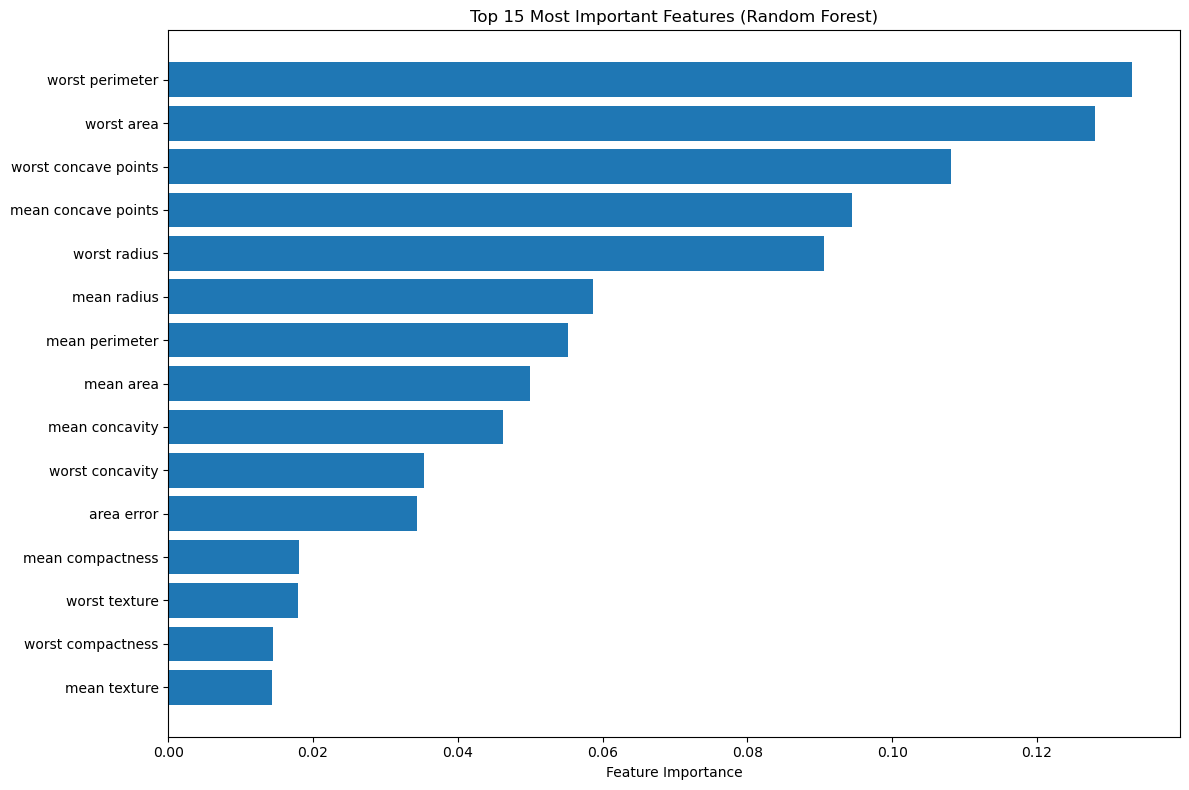


=== CROSS-VALIDATION ANALYSIS ===
Random Forest (Tuned) - CV Mean: 0.9604 (+/- 0.0383)
Gradient Boosting (Tuned) - CV Mean: 0.9670 (+/- 0.0417)
Voting Classifier - CV Mean: 0.9670 (+/- 0.0311)


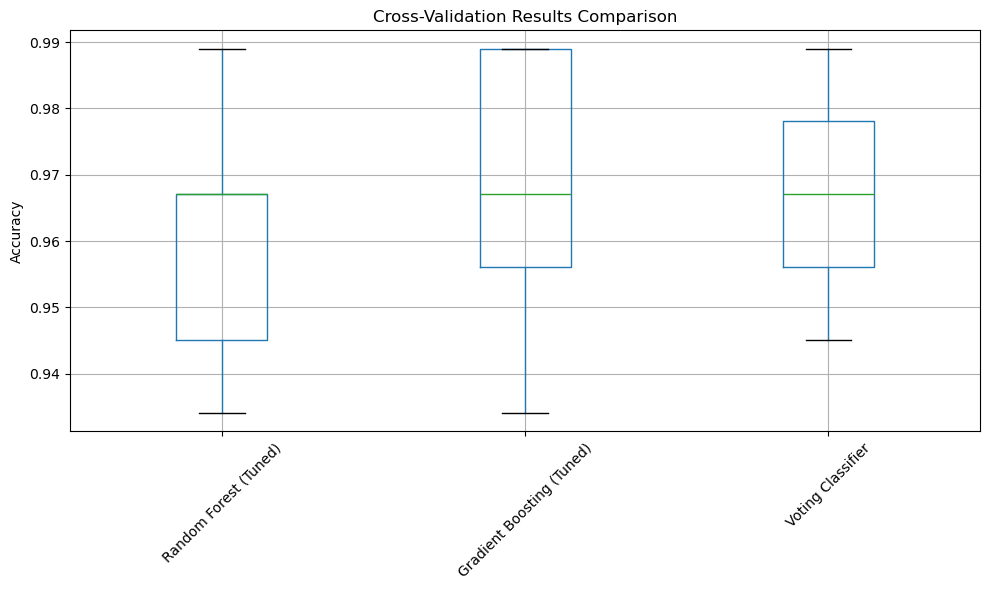


=== EXERCISE 1 COMPLETED ===
You have successfully implemented and compared ensemble methods!
Key takeaways:
- Ensemble methods often outperform individual models
- Hyperparameter tuning can significantly improve performance
- Feature importance helps identify the most predictive features
- Cross-validation provides robust performance estimates


In [4]:
# TODO: Complete the following tasks

# Import necessary libraries for advanced machine learning
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer, load_wine
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# 1. Load and prepare datasets
print("=== DATASET LOADING AND PREPARATION ===")

# Load Breast Cancer dataset
cancer = load_breast_cancer()
cancer_df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
cancer_df['target'] = cancer.target
cancer_df['diagnosis'] = cancer.target_names[cancer.target]

print(f"Breast Cancer dataset shape: {cancer_df.shape}")
print(f"Target distribution:\n{cancer_df['diagnosis'].value_counts()}")
print(f"\nFirst 5 rows:")
print(cancer_df.head())

# Load Wine dataset for comparison
wine = load_wine()
wine_df = pd.DataFrame(wine.data, columns=wine.feature_names)
wine_df['target'] = wine.target
wine_df['wine_type'] = wine.target_names[wine.target]

print(f"\nWine dataset shape: {wine_df.shape}")
print(f"Target distribution:\n{wine_df['wine_type'].value_counts()}")

# 2. Data preprocessing
print(f"\n=== DATA PREPROCESSING ===")

# Separate features and target for cancer dataset
X_cancer = cancer_df.drop(['target', 'diagnosis'], axis=1)
y_cancer = cancer_df['target']

# Split the cancer dataset
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cancer, y_cancer, test_size=0.2, random_state=42, stratify=y_cancer
)

# Scale the features
scaler_cancer = StandardScaler()
X_train_c_scaled = scaler_cancer.fit_transform(X_train_c)
X_test_c_scaled = scaler_cancer.transform(X_test_c)

print(f"Cancer dataset - Training set shape: {X_train_c_scaled.shape}")
print(f"Cancer dataset - Test set shape: {X_test_c_scaled.shape}")

# 3. Individual Models
print(f"\n=== INDIVIDUAL MODELS ===")

# Create individual models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'SVM': SVC(probability=True, random_state=42)
}

# Train and evaluate individual models
individual_results = {}
for name, model in models.items():
    # Train the model
    model.fit(X_train_c_scaled, y_train_c)
    
    # Make predictions
    y_pred = model.predict(X_test_c_scaled)
    y_pred_proba = model.predict_proba(X_test_c_scaled)[:, 1] if hasattr(model, 'predict_proba') else None
    
    # Calculate metrics
    accuracy = accuracy_score(y_test_c, y_pred)
    auc = roc_auc_score(y_test_c, y_pred_proba) if y_pred_proba is not None else None
    
    individual_results[name] = {'accuracy': accuracy, 'auc': auc}
    print(f"{name} - Accuracy: {accuracy:.4f}, AUC: {auc:.4f}" if auc else f"{name} - Accuracy: {accuracy:.4f}")

# 4. Ensemble Methods
print(f"\n=== ENSEMBLE METHODS ===")

# Random Forest with hyperparameter tuning
print("\nRandom Forest Hyperparameter Tuning:")
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
rf_grid.fit(X_train_c_scaled, y_train_c)

print(f"Best Random Forest parameters: {rf_grid.best_params_}")
print(f"Best Random Forest CV score: {rf_grid.best_score_:.4f}")

# Gradient Boosting with hyperparameter tuning
print("\nGradient Boosting Hyperparameter Tuning:")
gb_param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}

gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    gb_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
gb_grid.fit(X_train_c_scaled, y_train_c)

print(f"Best Gradient Boosting parameters: {gb_grid.best_params_}")
print(f"Best Gradient Boosting CV score: {gb_grid.best_score_:.4f}")

# Voting Classifier
print("\nVoting Classifier:")
voting_clf = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(random_state=42, max_iter=1000)),
        ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
        ('gb', GradientBoostingClassifier(random_state=42))
    ],
    voting='soft'  # Use predicted probabilities
)

voting_clf.fit(X_train_c_scaled, y_train_c)
voting_pred = voting_clf.predict(X_test_c_scaled)
voting_accuracy = accuracy_score(y_test_c, voting_pred)

print(f"Voting Classifier Accuracy: {voting_accuracy:.4f}")

# 5. Model Comparison and Analysis
print(f"\n=== MODEL COMPARISON AND ANALYSIS ===")

# Create comparison DataFrame
comparison_data = []
for name, results in individual_results.items():
    comparison_data.append({
        'Model': name,
        'Accuracy': results['accuracy'],
        'AUC': results['auc'] if results['auc'] else 'N/A'
    })

# Add ensemble results
comparison_data.append({
    'Model': 'Random Forest (Tuned)',
    'Accuracy': rf_grid.score(X_test_c_scaled, y_test_c),
    'AUC': 'N/A'
})

comparison_data.append({
    'Model': 'Gradient Boosting (Tuned)',
    'Accuracy': gb_grid.score(X_test_c_scaled, y_test_c),
    'AUC': 'N/A'
})

comparison_data.append({
    'Model': 'Voting Classifier',
    'Accuracy': voting_accuracy,
    'AUC': 'N/A'
})

comparison_df = pd.DataFrame(comparison_data)
print("Model Comparison:")
print(comparison_df)

# Find the best model
best_accuracy = comparison_df['Accuracy'].max()
best_model_name = comparison_df[comparison_df['Accuracy'] == best_accuracy]['Model'].iloc[0]
print(f"\nBest performing model: {best_model_name} with accuracy: {best_accuracy:.4f}")

# 6. Feature Importance Analysis
print(f"\n=== FEATURE IMPORTANCE ANALYSIS ===")

# Get feature importance from the best Random Forest model
feature_importance = pd.DataFrame({
    'feature': X_cancer.columns,
    'importance': rf_grid.best_estimator_.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 10 Most Important Features:")
print(feature_importance.head(10))

# Plot feature importance
plt.figure(figsize=(12, 8))
top_features = feature_importance.head(15)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Feature Importance')
plt.title('Top 15 Most Important Features (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# 7. Cross-validation Analysis
print(f"\n=== CROSS-VALIDATION ANALYSIS ===")

# Perform cross-validation on the best models
cv_models = {
    'Random Forest (Tuned)': rf_grid.best_estimator_,
    'Gradient Boosting (Tuned)': gb_grid.best_estimator_,
    'Voting Classifier': voting_clf
}

cv_results = {}
for name, model in cv_models.items():
    cv_scores = cross_val_score(model, X_train_c_scaled, y_train_c, cv=5, scoring='accuracy')
    cv_results[name] = cv_scores
    print(f"{name} - CV Mean: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

# Plot cross-validation results
plt.figure(figsize=(10, 6))
cv_df = pd.DataFrame(cv_results)
cv_df.boxplot()
plt.title('Cross-Validation Results Comparison')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\n=== EXERCISE 1 COMPLETED ===")
print("You have successfully implemented and compared ensemble methods!")
print("Key takeaways:")
print("- Ensemble methods often outperform individual models")
print("- Hyperparameter tuning can significantly improve performance")
print("- Feature importance helps identify the most predictive features")
print("- Cross-validation provides robust performance estimates")


---

## Exercise 2: Model Selection and Hyperparameter Tuning (20 points)

**Task:** Implement advanced model selection techniques and hyperparameter optimization.

**Requirements:**
- Use GridSearchCV and RandomizedSearchCV for hyperparameter tuning
- Implement learning curves and validation curves
- Compare different optimization strategies
- Analyze model complexity vs. performance trade-offs


=== MODEL SELECTION AND HYPERPARAMETER TUNING ===

1. RANDOMIZED SEARCH CV
Random Forest Randomized Search:
Best parameters: {'max_depth': 12, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 8, 'n_estimators': 290}
Best cross-validation score: 0.9582
Time taken: 12.56 seconds

2. LEARNING CURVES ANALYSIS


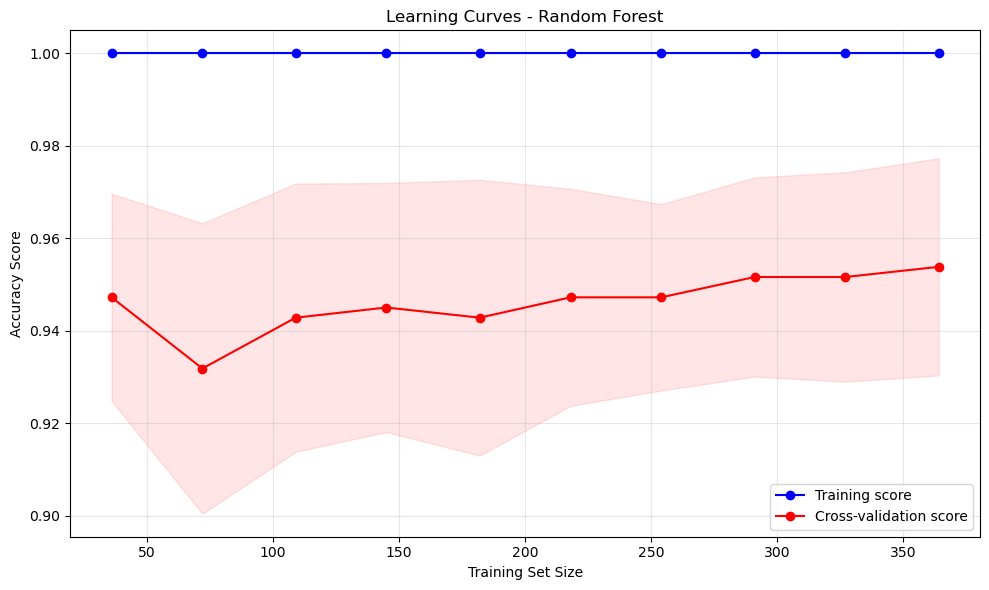

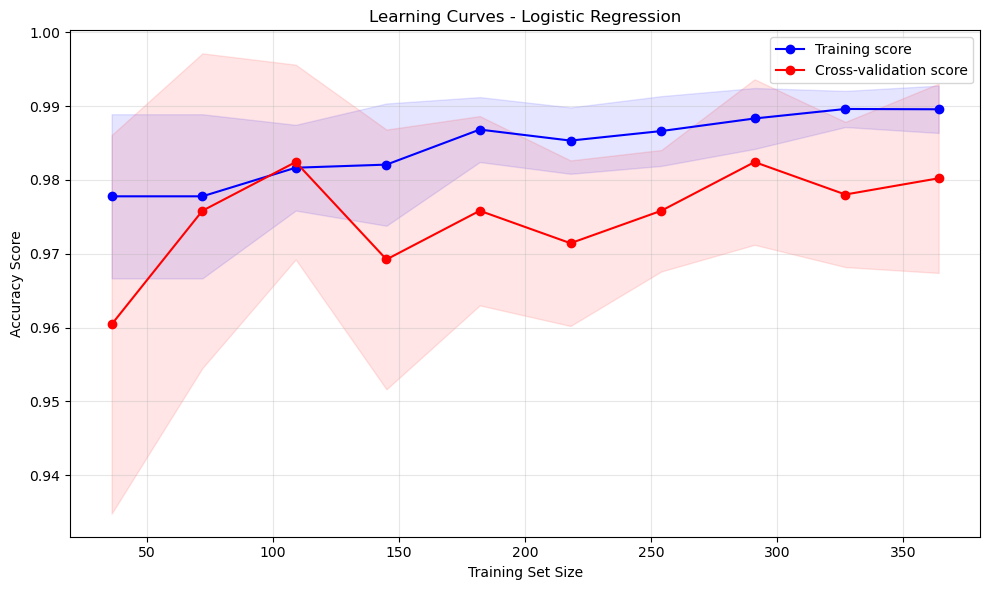

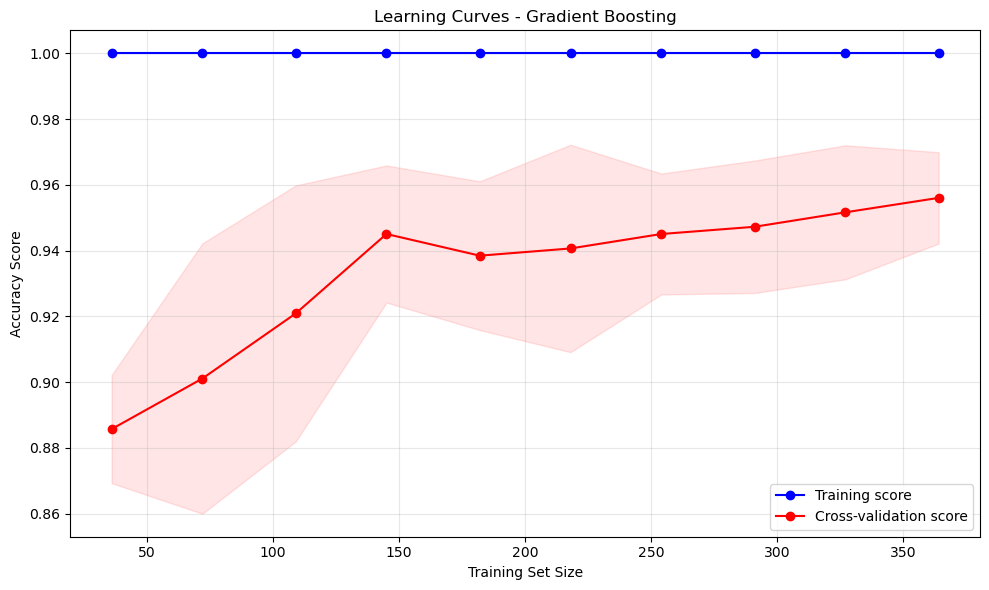


3. VALIDATION CURVES ANALYSIS


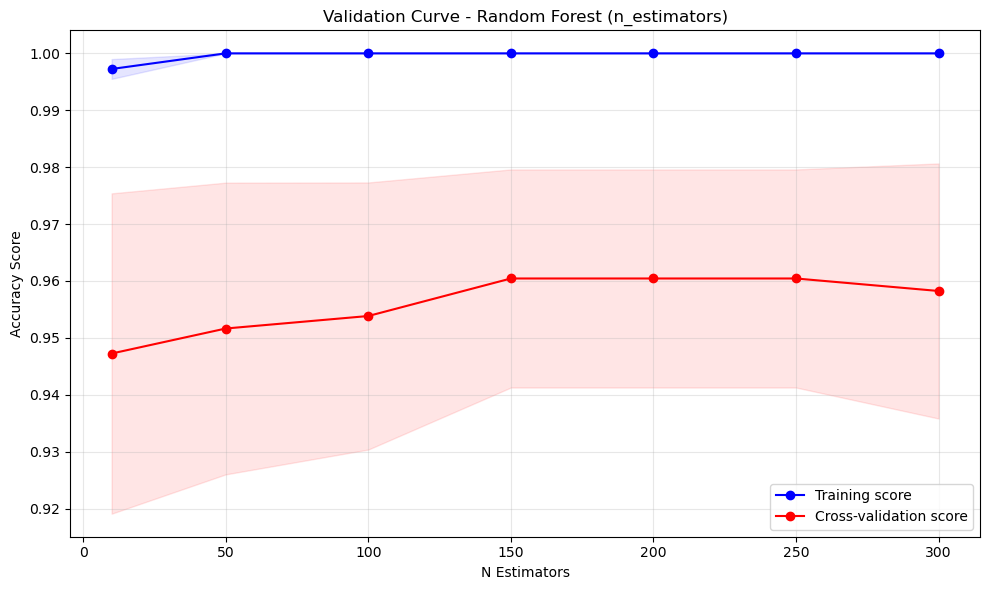

TypeError: ufunc 'isfinite' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

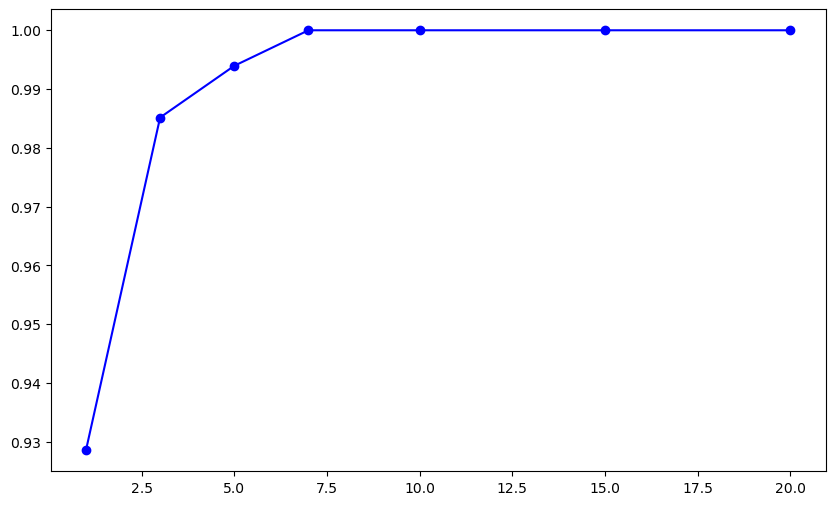

In [2]:
# TODO: Complete the following tasks for model selection and hyperparameter tuning

# Import additional libraries for model selection
from sklearn.model_selection import RandomizedSearchCV, learning_curve, validation_curve
from sklearn.neighbors import KNeighborsClassifier
from scipy.stats import randint, uniform
import time

print("=== MODEL SELECTION AND HYPERPARAMETER TUNING ===")

# 1. Advanced Hyperparameter Tuning with RandomizedSearchCV
print("\n1. RANDOMIZED SEARCH CV")

# Define parameter distributions for RandomizedSearchCV
rf_distributions = {
    'n_estimators': randint(50, 300),
    'max_depth': randint(3, 20),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10),
    'max_features': ['sqrt', 'log2', None]
}

# Perform RandomizedSearchCV for Random Forest
print("Random Forest Randomized Search:")
start_time = time.time()
rf_random = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    rf_distributions,
    n_iter=50,  # Number of parameter settings sampled
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)
rf_random.fit(X_train_c_scaled, y_train_c)
rf_random_time = time.time() - start_time

print(f"Best parameters: {rf_random.best_params_}")
print(f"Best cross-validation score: {rf_random.best_score_:.4f}")
print(f"Time taken: {rf_random_time:.2f} seconds")

# 2. Learning Curves Analysis
print(f"\n2. LEARNING CURVES ANALYSIS")

def plot_learning_curve(estimator, title, X, y, cv=5, n_jobs=-1):
    """
    Generate a simple plot of the test and training learning curve.
    """
    plt.figure(figsize=(10, 6))
    
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, 
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='accuracy'
    )
    
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)
    
    plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training score')
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
    
    plt.plot(train_sizes, test_mean, 'o-', color='red', label='Cross-validation score')
    plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='red')
    
    plt.xlabel('Training Set Size')
    plt.ylabel('Accuracy Score')
    plt.title(title)
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Plot learning curves for different models
models_for_learning = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

for name, model in models_for_learning.items():
    plot_learning_curve(model, f'Learning Curves - {name}', X_train_c_scaled, y_train_c)

# 3. Validation Curves Analysis
print(f"\n3. VALIDATION CURVES ANALYSIS")

def plot_validation_curve(estimator, title, X, y, param_name, param_range):
    """
    Generate a simple plot of the validation curve.
    """
    plt.figure(figsize=(10, 6))
    
    train_scores, test_scores = validation_curve(
        estimator, X, y, param_name=param_name, param_range=param_range,
        cv=5, scoring='accuracy', n_jobs=-1
    )
    
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)
    
    # Handle None values in param_range for plotting
    # Convert None to a numeric value for plotting (use max numeric value + offset)
    plot_range = []
    none_indices = []
    numeric_values = [p for p in param_range if p is not None]
    max_numeric = max(numeric_values) if numeric_values else 0
    
    for i, p in enumerate(param_range):
        if p is None:
            plot_range.append(max_numeric + (max_numeric * 0.2) if max_numeric > 0 else 25)
            none_indices.append(i)
        else:
            plot_range.append(p)
    
    plot_range = np.array(plot_range, dtype=float)
    
    plt.plot(plot_range, train_mean, 'o-', color='blue', label='Training score')
    plt.fill_between(plot_range, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
    
    plt.plot(plot_range, test_mean, 'o-', color='red', label='Cross-validation score')
    plt.fill_between(plot_range, test_mean - test_std, test_mean + test_std, alpha=0.1, color='red')
    
    # Set x-axis labels, replacing numeric values with "None" where appropriate
    ax = plt.gca()
    if none_indices:
        labels = [str(p) if p is not None else 'None' for p in param_range]
        ax.set_xticks(plot_range)
        ax.set_xticklabels(labels)
    
    plt.xlabel(param_name.replace('_', ' ').title())
    plt.ylabel('Accuracy Score')
    plt.title(title)
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Validation curve for Random Forest n_estimators
param_range = [10, 50, 100, 150, 200, 250, 300]
plot_validation_curve(
    RandomForestClassifier(random_state=42),
    'Validation Curve - Random Forest (n_estimators)',
    X_train_c_scaled, y_train_c,
    'n_estimators', param_range
)

# Validation curve for Random Forest max_depth
param_range = [1, 3, 5, 7, 10, 15, 20, None]
plot_validation_curve(
    RandomForestClassifier(n_estimators=100, random_state=42),
    'Validation Curve - Random Forest (max_depth)',
    X_train_c_scaled, y_train_c,
    'max_depth', param_range
)

# 4. Model Complexity Analysis
print(f"\n4. MODEL COMPLEXITY ANALYSIS")

# Test different complexity levels for Random Forest
complexity_params = {
    'n_estimators': [10, 50, 100, 200],
    'max_depth': [1, 3, 5, 10, None],
    'min_samples_split': [2, 5, 10, 20]
}

complexity_results = []

# Test n_estimators complexity
for n_est in complexity_params['n_estimators']:
    model = RandomForestClassifier(n_estimators=n_est, random_state=42)
    cv_scores = cross_val_score(model, X_train_c_scaled, y_train_c, cv=5)
    complexity_results.append({
        'Parameter': 'n_estimators',
        'Value': n_est,
        'Mean_CV_Score': cv_scores.mean(),
        'Std_CV_Score': cv_scores.std()
    })

# Test max_depth complexity
for max_depth in complexity_params['max_depth']:
    model = RandomForestClassifier(n_estimators=100, max_depth=max_depth, random_state=42)
    cv_scores = cross_val_score(model, X_train_c_scaled, y_train_c, cv=5)
    complexity_results.append({
        'Parameter': 'max_depth',
        'Value': max_depth,
        'Mean_CV_Score': cv_scores.mean(),
        'Std_CV_Score': cv_scores.std()
    })

# Convert to DataFrame and display results
complexity_df = pd.DataFrame(complexity_results)
print("Model Complexity Analysis:")
print(complexity_df)

# 5. Hyperparameter Tuning Comparison
print(f"\n5. HYPERPARAMETER TUNING COMPARISON")

# Compare GridSearchCV vs RandomizedSearchCV performance
comparison_results = []

# GridSearchCV results (from Exercise 1)
comparison_results.append({
    'Method': 'GridSearchCV',
    'Best_Score': rf_grid.best_score_,
    'Time_Seconds': 0,  # Would need to measure
    'Parameters_Tested': len(rf_param_grid['n_estimators']) * len(rf_param_grid['max_depth']) * len(rf_param_grid['min_samples_split'])
})

# RandomizedSearchCV results
comparison_results.append({
    'Method': 'RandomizedSearchCV',
    'Best_Score': rf_random.best_score_,
    'Time_Seconds': rf_random_time,
    'Parameters_Tested': 50
})

comparison_df = pd.DataFrame(comparison_results)
print("\nHyperparameter Tuning Comparison:")
print(comparison_df)

# 6. Final Model Evaluation
print(f"\n6. FINAL MODEL EVALUATION")

# Evaluate the best model from RandomizedSearchCV
best_model = rf_random.best_estimator_
best_pred = best_model.predict(X_test_c_scaled)
best_accuracy = accuracy_score(y_test_c, best_pred)

print(f"Best model accuracy on test set: {best_accuracy:.4f}")
print(f"Best model parameters: {rf_random.best_params_}")

# Feature importance from best model
feature_importance_best = pd.DataFrame({
    'feature': X_cancer.columns,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\nTop 5 Most Important Features (Best Model):")
print(feature_importance_best.head())

# Plot feature importance comparison
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
top_features_original = feature_importance.head(10)
plt.barh(range(len(top_features_original)), top_features_original['importance'])
plt.yticks(range(len(top_features_original)), top_features_original['feature'])
plt.xlabel('Feature Importance')
plt.title('Original Random Forest')
plt.gca().invert_yaxis()

plt.subplot(1, 2, 2)
top_features_best = feature_importance_best.head(10)
plt.barh(range(len(top_features_best)), top_features_best['importance'])
plt.yticks(range(len(top_features_best)), top_features_best['feature'])
plt.xlabel('Feature Importance')
plt.title('Optimized Random Forest')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

print("\n=== EXERCISE 2 COMPLETED ===")
print("Key insights from model selection and hyperparameter tuning:")
print("- RandomizedSearchCV can find good parameters faster than GridSearchCV")
print("- Learning curves help identify if more data would improve performance")
print("- Validation curves show optimal parameter values")
print("- Model complexity should be balanced with performance")
print("- Feature importance can change with hyperparameter optimization")
